# OBJECT LOCALIZATION USING CNN

# IMPORT LIBRARIES

In [1]:
import numpy as np  # numerical operations
import cv2  # image processing
import matplotlib.pyplot as plt  # visualization
from sklearn.model_selection import train_test_split  # dataset split

from tensorflow.keras.models import Sequential  # CNN model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense  # layers
from tensorflow.keras.callbacks import EarlyStopping  # early stopping

# CONFIGURATION

In [2]:
Image_Size = 128  # input image size
sample = 100

# CREATE SYNTHETIC DATASET

In [3]:
def create_dataset(samples=sample):  # dataset function

    images = []  # store images
    labels = []  # store bounding boxes

    for _ in range(samples):  # loop for dataset creation

        img = np.zeros((Image_Size, Image_Size, 3), dtype=np.uint8)  # black image

        x = np.random.randint(20, 90)  # random x position
        y = np.random.randint(20, 90)  # random y position
        w = np.random.randint(20, 40)  # random width
        h = np.random.randint(20, 40)  # random height

        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 255), -1)  # draw object

        x_center = (x + w / 2) / Image_Size  # normalize center x
        y_center = (y + h / 2) / Image_Size  # normalize center y
        norm_w = w / Image_Size  # normalize width
        norm_h = h / Image_Size  # normalize height

        labels.append([x_center, y_center, norm_w, norm_h])  # store label
        images.append(img / 255.0)  # normalize image

    return np.array(images), np.array(labels)  # return dataset

# GENERATE DATASET

In [4]:
X, y = create_dataset(sample)  # create images + labels

print("Dataset Created")  # status
print("Images Shape:", X.shape)  # image shape
print("Labels Shape:", y.shape)  # label shape

Dataset Created
Images Shape: (100, 128, 128, 3)
Labels Shape: (100, 4)


# TRAIN TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)  # split dataset

# BUILD CNN MODEL

In [6]:
model = Sequential([

    Input(shape=(Image_Size, Image_Size, 3)),  # input layer

    Conv2D(8, (3,3), activation="relu"),  # feature extractor 1
    MaxPooling2D(),  # downsample

    Conv2D(16, (3,3), activation="relu"),  # feature extractor 1
    MaxPooling2D(),  # downsample

    Conv2D(32, (3,3), activation="relu"),  # feature extractor 2
    MaxPooling2D(),  # downsample

    Conv2D(64, (3,3), activation="relu"),  # feature extractor 3
    MaxPooling2D(),  # downsample

    Flatten(),  # flatten features

    Dense(128, activation="relu"),  # fully connected layer

    Dense(4, activation="sigmoid")  # output bounding box
])

model.summary()  # model summary

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,084 (1.22 MB)

 Trainable params: 320,084 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILE MODEL

In [7]:
model.compile(
    optimizer="adam",  # optimizer
    loss="mse"  # regression loss
)

# EARLY STOPPING

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",  # monitor validation loss
    patience=3,  # stop if no improvement
    restore_best_weights=True  # keep best model
)

# TRAIN MODEL

In [9]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 590ms/step - loss: 0.0432 - val_loss: 0.0177
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - loss: 0.0109 - val_loss: 0.0147
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - loss: 0.0097 - val_loss: 0.0055
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - loss: 0.0043 - val_loss: 0.0046
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 0.0046 - val_loss: 0.0030
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 0.0033 - val_loss: 0.0055
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 0.0021 - val_loss: 0.0025
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 0.0019 - val_loss: 0.0032
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 0.0016 - val_loss: 0.0031
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.0013 - val_lo

# LOSS PLOT

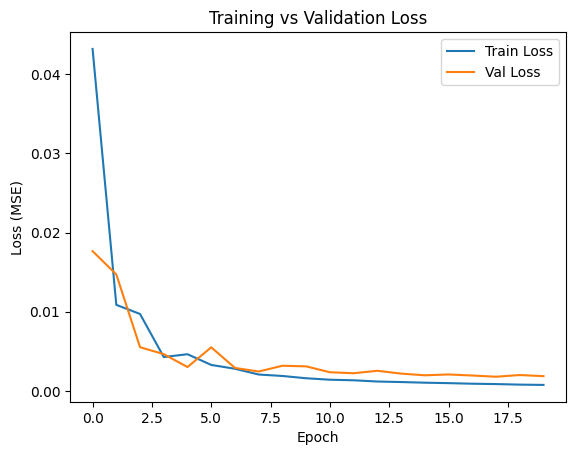

In [10]:
plt.plot(history.history['loss'], label="Train Loss")  # training loss
plt.plot(history.history['val_loss'], label="Val Loss")  # validation loss
plt.title("Training vs Validation Loss")  # title
plt.xlabel("Epoch")  # x-axis
plt.ylabel("Loss (MSE)")  # y-axis
plt.legend()  # legend
plt.show()  # display graph

# IoU FUNCTION

In [11]:
def IoU(box1, box2):  # IoU function

    x1, y1, w1, h1 = box1  # predicted box
    x2, y2, w2, h2 = box2  # true box

    x1_min = x1 - w1/2  # left
    x1_max = x1 + w1/2  # right
    y1_min = y1 - h1/2  # top
    y1_max = y1 + h1/2  # bottom

    x2_min = x2 - w2/2  # left
    x2_max = x2 + w2/2  # right
    y2_min = y2 - h2/2  # top
    y2_max = y2 + h2/2  # bottom

    inter_xmin = max(x1_min, x2_min)  # intersection left
    inter_xmax = min(x1_max, x2_max)  # intersection right
    inter_ymin = max(y1_min, y2_min)  # intersection top
    inter_ymax = min(y1_max, y2_max)  # intersection bottom

    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)  # overlap

    union = (w1 * h1 + w2 * h2 - inter_area)  # union

    return inter_area / (union + 1e-6)  # IoU score

# VISUALIZATION (TRUE VS PREDICTED)

In [12]:
def draw_box(img, box, color):  # draw function

    x, y, w, h = box  # unpack

    x *= Image_Size  # convert x
    y *= Image_Size  # convert y
    w *= Image_Size  # convert w
    h *= Image_Size  # convert h

    x1 = int(x - w/2)  # left
    y1 = int(y - h/2)  # top
    x2 = int(x + w/2)  # right
    y2 = int(y + h/2)  # bottom

    cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)  # draw box


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


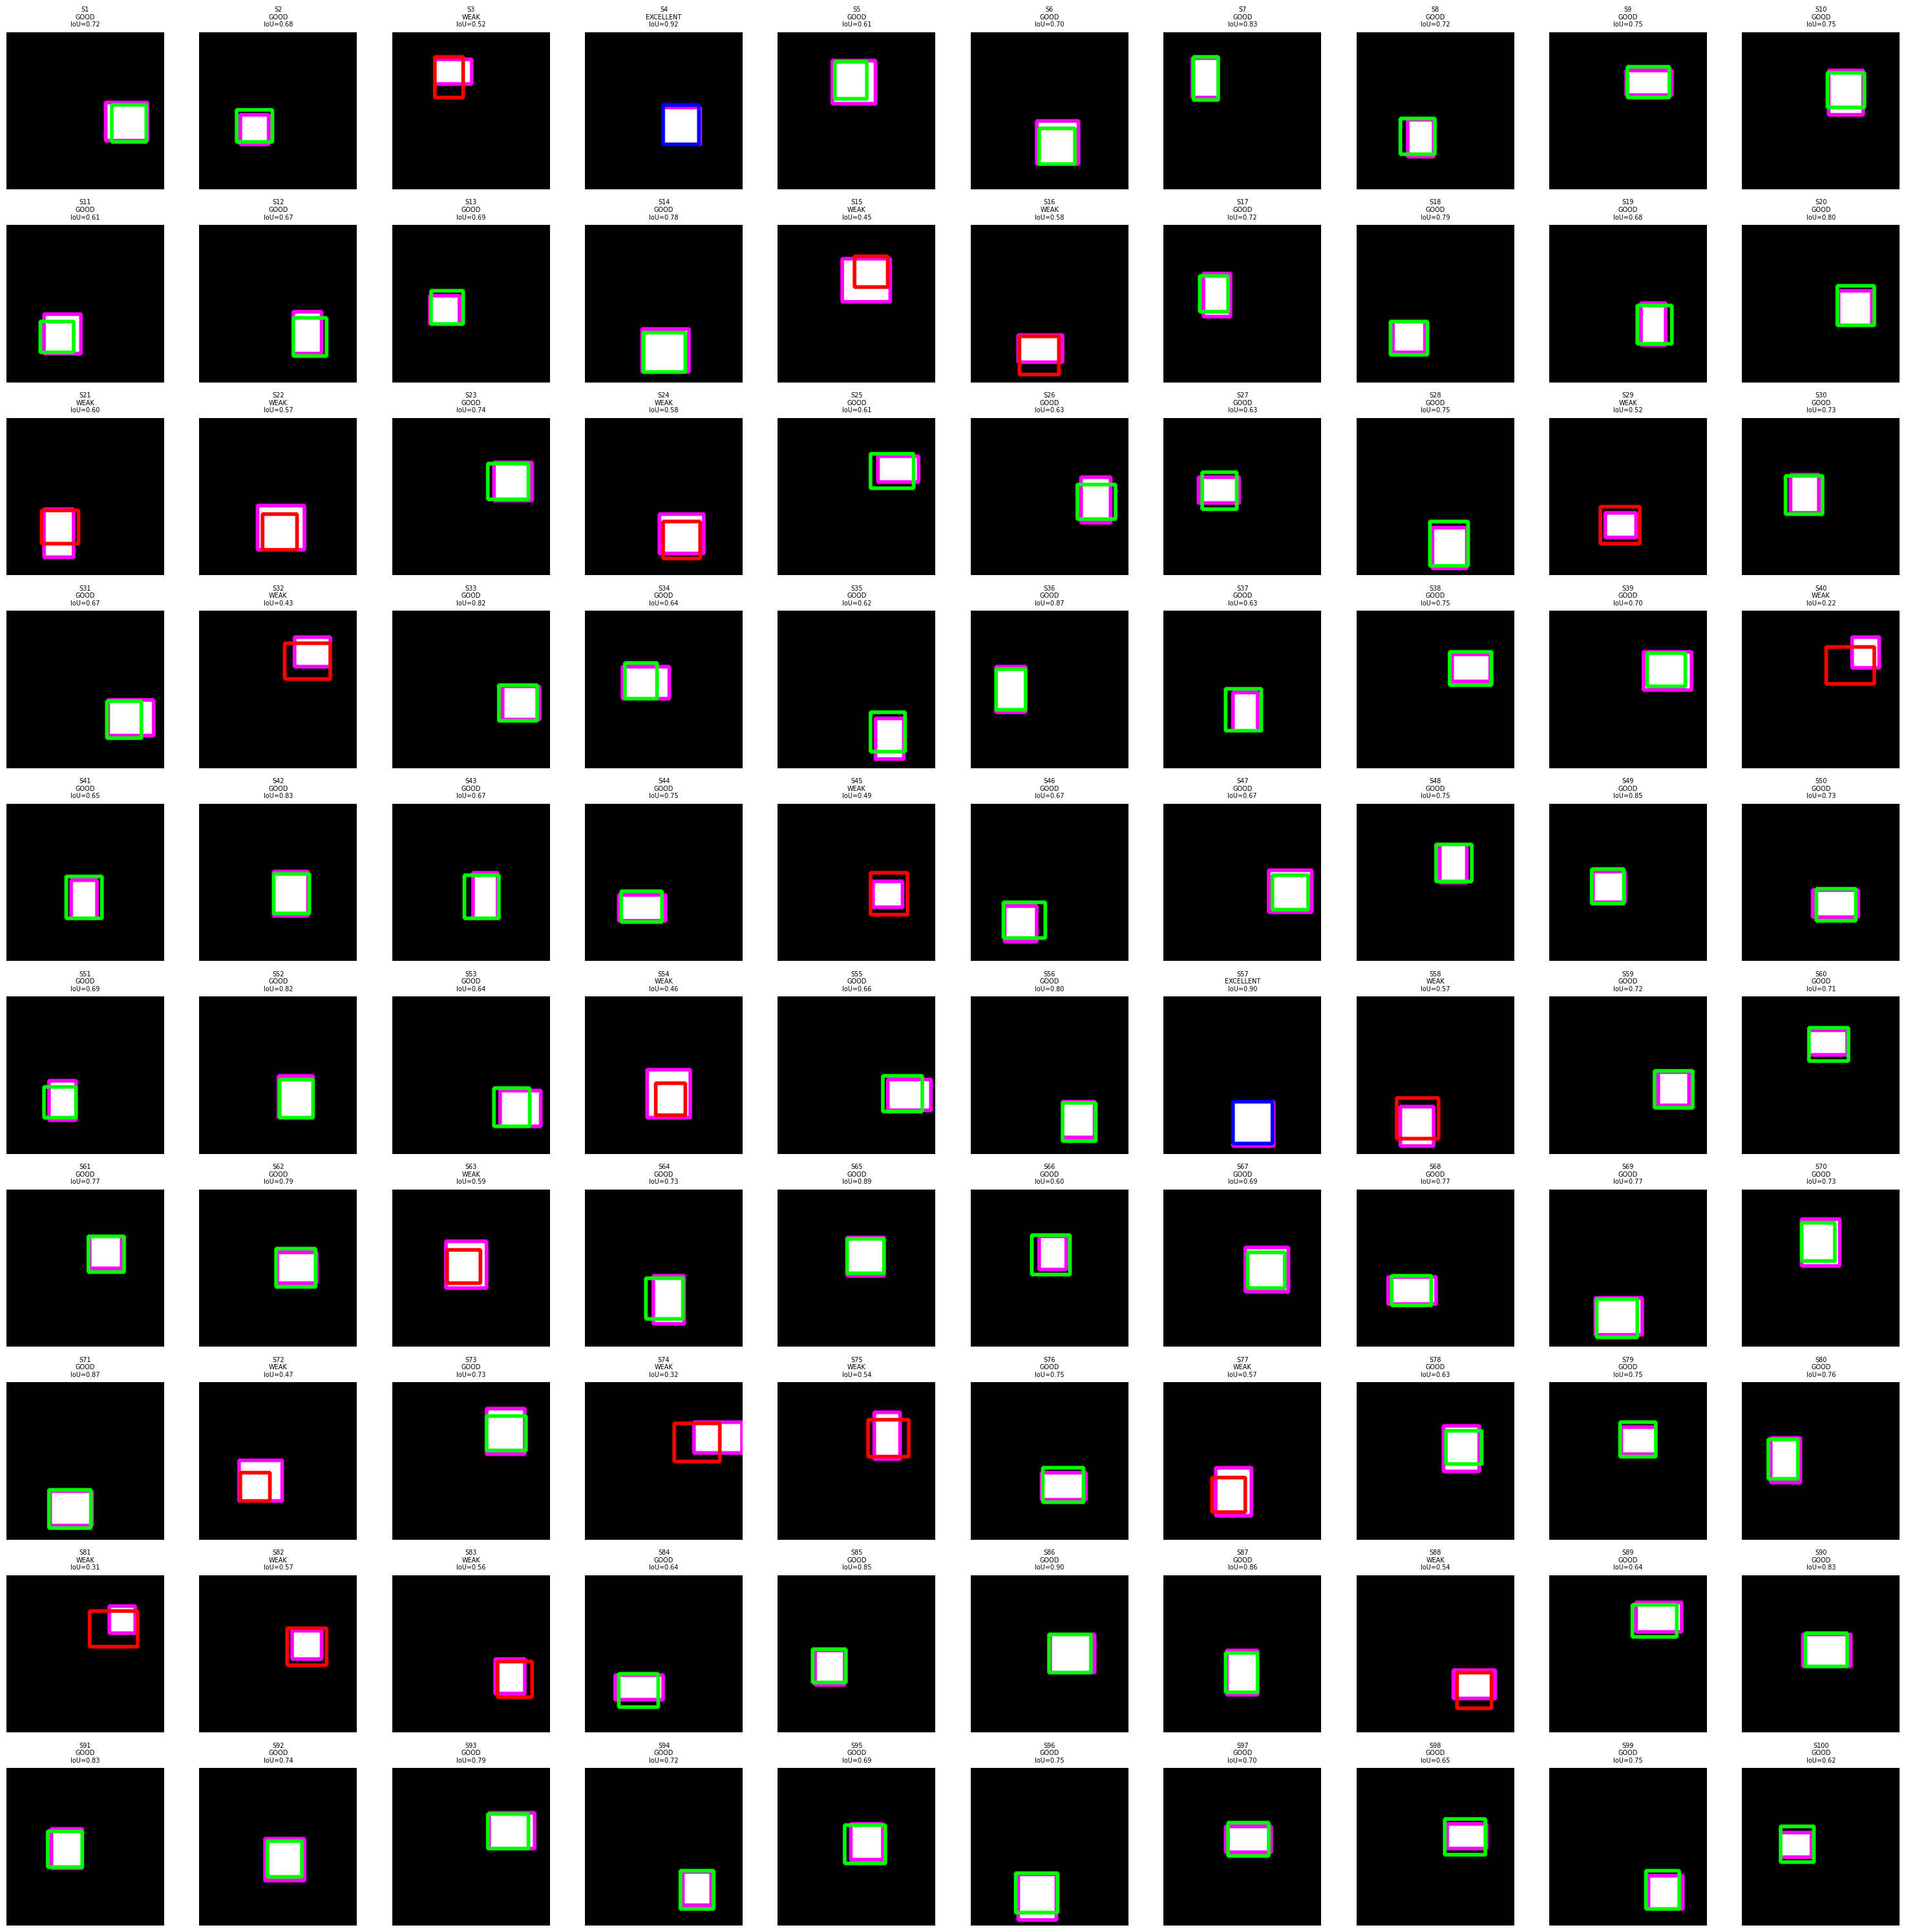

Excellent = Green
Good = Blue
Weak = Red


In [13]:
preds = model.predict(X)

plt.figure(figsize=(30,30))

for i in range(sample):
    img = (X[i] * 255).astype(np.uint8).copy()
    iou = IoU(preds[i], y[i])

    draw_box(img, y[i], (255,0,255))

    if iou >= 0.90:
        draw_box(img, preds[i], (255,0,0))
        status = "EXCELLENT"

    elif iou >= 0.60:
        draw_box(img, preds[i], (0,255,0))
        status = "GOOD"

    else:
        draw_box(img, preds[i], (0,0,255))
        status = "WEAK"

    plt.subplot(10,10,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"S{i+1}\n{status}\nIoU={iou:.2f}", fontsize=7)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Excellent = Green")
print("Good = Blue")
print("Weak = Red")

In [14]:
ious = [IoU(preds[i], y[i]) for i in range(len(preds))]

excellent = 0
good = 0
weak = 0

for iou in ious:

    if iou >= 0.90:
        excellent += 1
    elif iou >= 0.60:
        good += 1
    else:
        weak += 1

print("=" * 80)
print("LOCALIZATION REPORT")
print("=" * 80)

for i in range(len(preds)):

    pred_box = np.round(preds[i], 3)
    true_box = np.round(y[i], 3)
    iou = ious[i]

    if iou >= 0.90:
        status = "✔ EXCELLENT"
    elif iou >= 0.60:
        status = "➜ GOOD"
    else:
        status = "✖ WEAK"

    print(f"\nSample {i+1}")
    print("-" * 60)
    print("True Box      :", true_box)
    print("Predicted Box :", pred_box)
    print("IoU           :", round(iou, 3))
    print("Status        :", status)

LOCALIZATION REPORT

Sample 1
------------------------------------------------------------
True Box      : [0.758 0.566 0.266 0.242]
Predicted Box : [0.775 0.583 0.218 0.23 ]
IoU           : 0.721
Status        : ➜ GOOD

Sample 2
------------------------------------------------------------
True Box      : [0.348 0.617 0.18  0.188]
Predicted Box : [0.353 0.601 0.224 0.204]
IoU           : 0.681
Status        : ➜ GOOD

Sample 3
------------------------------------------------------------
True Box      : [0.383 0.25  0.234 0.156]
Predicted Box : [0.358 0.289 0.181 0.255]
IoU           : 0.519
Status        : ✖ WEAK

Sample 4
------------------------------------------------------------
True Box      : [0.609 0.594 0.234 0.234]
Predicted Box : [0.608 0.586 0.229 0.25 ]
IoU           : 0.916
Status        : ✔ EXCELLENT

Sample 5
------------------------------------------------------------
True Box      : [0.48  0.316 0.273 0.273]
Predicted Box : [0.463 0.308 0.2   0.23 ]
IoU           : 0.61

In [15]:
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print("Total Samples :", len(ious))
print(f"Excellent (>=0.90) : {excellent} -> {(excellent/len(ious))*100:.2f}%")
print(f"Good (>=0.60)      : {good} -> {(good/len(ious))*100:.2f}%")
print(f"Weak (<0.60)       : {weak} -> {(weak/len(ious))*100:.2f}%")
print("Average IoU   :", round(np.mean(ious), 3))


FINAL SUMMARY
Total Samples : 100
Excellent (>=0.90) : 2 -> 2.00%
Good (>=0.60)      : 77 -> 77.00%
Weak (<0.60)       : 21 -> 21.00%
Average IoU   : 0.684
